In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
from pathlib import Path
import pandas as pd

base_dir = Path().resolve()

# Build the path to the parquet file relative to this notebook
file_path = base_dir.parent / 'data' / 'medicare_data_cleaned.parquet'

if not file_path.exists():
    print(f"File not found: {file_path}")
    print("Files in directory:", list(file_path.parent.glob("*")))
else:
    df = pd.read_parquet(file_path)

In [27]:
common_drgs = df['DRG_Cd'].value_counts(
)[df['DRG_Cd'].value_counts() > 20].index

df['drg_grouped'] = df['DRG_Cd'].apply(
    lambda x: x if x in common_drgs else 'Other')

In [28]:
import numpy as np
X = df.drop(columns = ['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg',
            'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt','Rndrng_Prvdr_Org_Name',  'Rndrng_Prvdr_City',    
        'Rndrng_Prvdr_St',  'Rndrng_Prvdr_State_Abrvtn'])

y = df['Avg_Mdcr_Pymt_Amt']

In [29]:
X

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,DRG_Cd,year,RUCA_category,drg_grouped
0,010001,1.0,36301.0,023,2021,metro_core,023
1,010001,1.0,36301.0,024,2021,metro_core,024
2,010001,1.0,36301.0,025,2021,metro_core,025
3,010001,1.0,36301.0,038,2021,metro_core,038
4,010001,1.0,36301.0,039,2021,metro_core,039
...,...,...,...,...,...,...,...
444153,670300,48.0,76065.0,291,2021,metro_core,291
444154,670300,48.0,76065.0,871,2021,metro_core,871
444155,670309,48.0,76063.0,177,2021,metro_core,177
444156,670309,48.0,76063.0,291,2021,metro_core,291


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Rndrng_Prvdr_CCN', 'DRG_Cd',
                    'RUCA_category', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'drg_grouped']

numeric_cols = ['year']  

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ("preprocess", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 6770.069276664461
MSE: 111905188.19587426
RMSE: 10578.524859160385
R²: 0.67633179960698


In [37]:
import optuna
from sklearn.metrics import f1_score 
from xgboost import XGBRegressor

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0)
    }

    # Transform categorical features to numeric using preprocessor
    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)

    xgb = XGBRegressor(**param)
    xgb.fit(X_train_enc, y_train)
    
    y_pred = xgb.predict(X_test_enc)
    # For regression, you may want to use a regression metric, e.g., neg_mean_absolute_error
    mae = mean_absolute_error(y_test, y_pred)

    return mae


optuna_study = optuna.create_study(direction='minimize')
optuna_study.optimize(objective, n_trials=100)

print("Best parameters:", optuna_study.best_params)
print("Best mae score:", optuna_study.best_value)

[I 2025-06-28 13:23:47,590] A new study created in memory with name: no-name-7c81ddcd-cea5-4dbd-b2c7-7f0cb3823de0
[I 2025-06-28 13:23:50,083] Trial 0 finished with value: 3642.2723639311753 and parameters: {'n_estimators': 199, 'max_depth': 9, 'learning_rate': 0.09570288386910596, 'gamma': 3.6164769927197904}. Best is trial 0 with value: 3642.2723639311753.
[I 2025-06-28 13:23:51,592] Trial 1 finished with value: 2742.1964212159696 and parameters: {'n_estimators': 116, 'max_depth': 9, 'learning_rate': 0.28245995916243427, 'gamma': 1.2768980151494485}. Best is trial 1 with value: 2742.1964212159696.
[I 2025-06-28 13:23:53,944] Trial 2 finished with value: 5779.12373090196 and parameters: {'n_estimators': 172, 'max_depth': 10, 'learning_rate': 0.031225180273314744, 'gamma': 3.549894308593258}. Best is trial 1 with value: 2742.1964212159696.
[I 2025-06-28 13:23:55,347] Trial 3 finished with value: 2817.35493712279 and parameters: {'n_estimators': 127, 'max_depth': 8, 'learning_rate': 0.27

Best parameters: {'n_estimators': 293, 'max_depth': 8, 'learning_rate': 0.29953669462009214, 'gamma': 0.6897817705967019}
Best mae score: 1996.8401398791564


In [118]:
import optuna.visualization as vis

vis.plot_optimization_history(optuna_study).show()
vis.plot_param_importances(optuna_study).show()

In [128]:
# Re-create and train model using best parameters from Optuna
xgb_optuna = XGBRegressor(**optuna_study.best_params)
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

xgb_optuna.fit(X_train_enc, y_train)

# Make predictions
y_pred_optuna = xgb_optuna.predict(X_test_enc)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred_optuna))
print("MSE:", mean_squared_error(y_test, y_pred_optuna))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_optuna)))
print("R²:", r2_score(y_test, y_pred_optuna))

MAE: 1800.155469702482
MSE: 22949252.191440713
RMSE: 4790.537776851437
R²: 0.9336228884744144


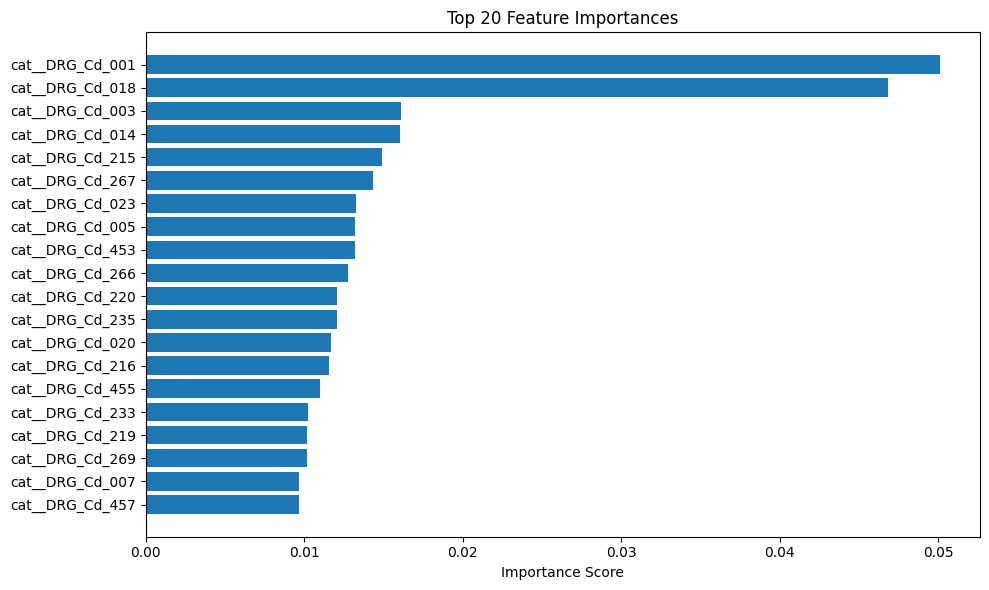

In [ ]:
# Get feature names AFTER fitting the preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out(X_train.columns)

# Train model with best Optuna params
xgb_optuna = XGBRegressor(**optuna_study.best_params)
xgb_optuna.fit(X_train_transformed, y_train)

# Get importances
importances = xgb_optuna.feature_importances_

# Make a DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [57]:
import joblib

# Save the full pipeline (preprocessing + model)
joblib.dump(model, "xgb_pipeline.joblib")

['xgb_pipeline.joblib']